# Treinamento KWS com Google Speech Commands Dataset

Importar bibliotecas

In [9]:
import os, pathlib, tarfile, urllib.request, random, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns
import json

Download do Google Speech Commands Dataset

In [19]:
import ssl
import urllib.request
import pathlib
import tarfile

DATASET_URL = 'https://download.tensorflow.org/data/speech_commands_v0.02.tar.gz'
DATASET_TAR = 'speech_commands_v0.02.tar.gz'
DATASET_DIR = pathlib.Path('speech_commands_v0.02')

print("Iniciando download (ignorando verificação SSL)...")

# Cria um contexto que não verifica certificados
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

# Abre a URL e baixa o arquivo manualmente para garantir o uso do contexto
with urllib.request.urlopen(DATASET_URL, context=ctx) as response, open(DATASET_TAR, 'wb') as out_file:
    out_file.write(response.read())

print("Extraindo arquivos...")
with tarfile.open(DATASET_TAR) as tar:
    tar.extractall(DATASET_DIR)

all_classes = sorted([d.name for d in DATASET_DIR.iterdir()
                       if d.is_dir() and not d.name.startswith('_')])
print(f"\n{len(all_classes)} classes disponíveis:")
print(', '.join(all_classes))

Iniciando download (ignorando verificação SSL)...
Extraindo arquivos...

35 classes disponíveis:
backward, bed, bird, cat, dog, down, eight, five, follow, forward, four, go, happy, house, learn, left, marvin, nine, no, off, on, one, right, seven, sheila, six, stop, three, tree, two, up, visual, wow, yes, zero


In [20]:
TARGET_CLASSES = ['yes', 'no', 'on', 'off']    # palavras-alvo
SILENCE_CLASS = 'silence'
ALL_LABELS = TARGET_CLASSES + [SILENCE_CLASS]
NUM_CLASSES = len(ALL_LABELS)
LABEL2IDX = {lbl : i for i, lbl in enumerate(ALL_LABELS)}

SAMPLE_RATE = 16000
DURATION = 1.0       # segundos
NUM_SAMPLES = int(SAMPLE_RATE * DURATION)

N_MFCC = 40
N_FFT = 512
HOP_LENGTH = 160   # 10 ms
WIN_LENGTH = 400   # 25 ms
MAX_FRAMES = 49    # frames usados pelo modelo (pad/truncate)

SAMPLES_PER_CLASS = 1500    # arquivos por classe-alvo
SILENCE_SAMPLES = 1500      # amostras de silêncio sintético
TEST_SIZE = 0.15
VAL_SIZE = 0.15
BATCH_SIZE = 64
EPOCHS = 50
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

[yes] Shape MFCC: (49, 40, 1)  |  min=-7.96  max=1.90
[no] Shape MFCC: (49, 40, 1)  |  min=-6.45  max=1.01
[on] Shape MFCC: (49, 40, 1)  |  min=-7.14  max=2.10
[off] Shape MFCC: (49, 40, 1)  |  min=-6.48  max=1.67
[silence] Shape MFCC: (49, 40, 1)  |  min=-15.28  max=0.93


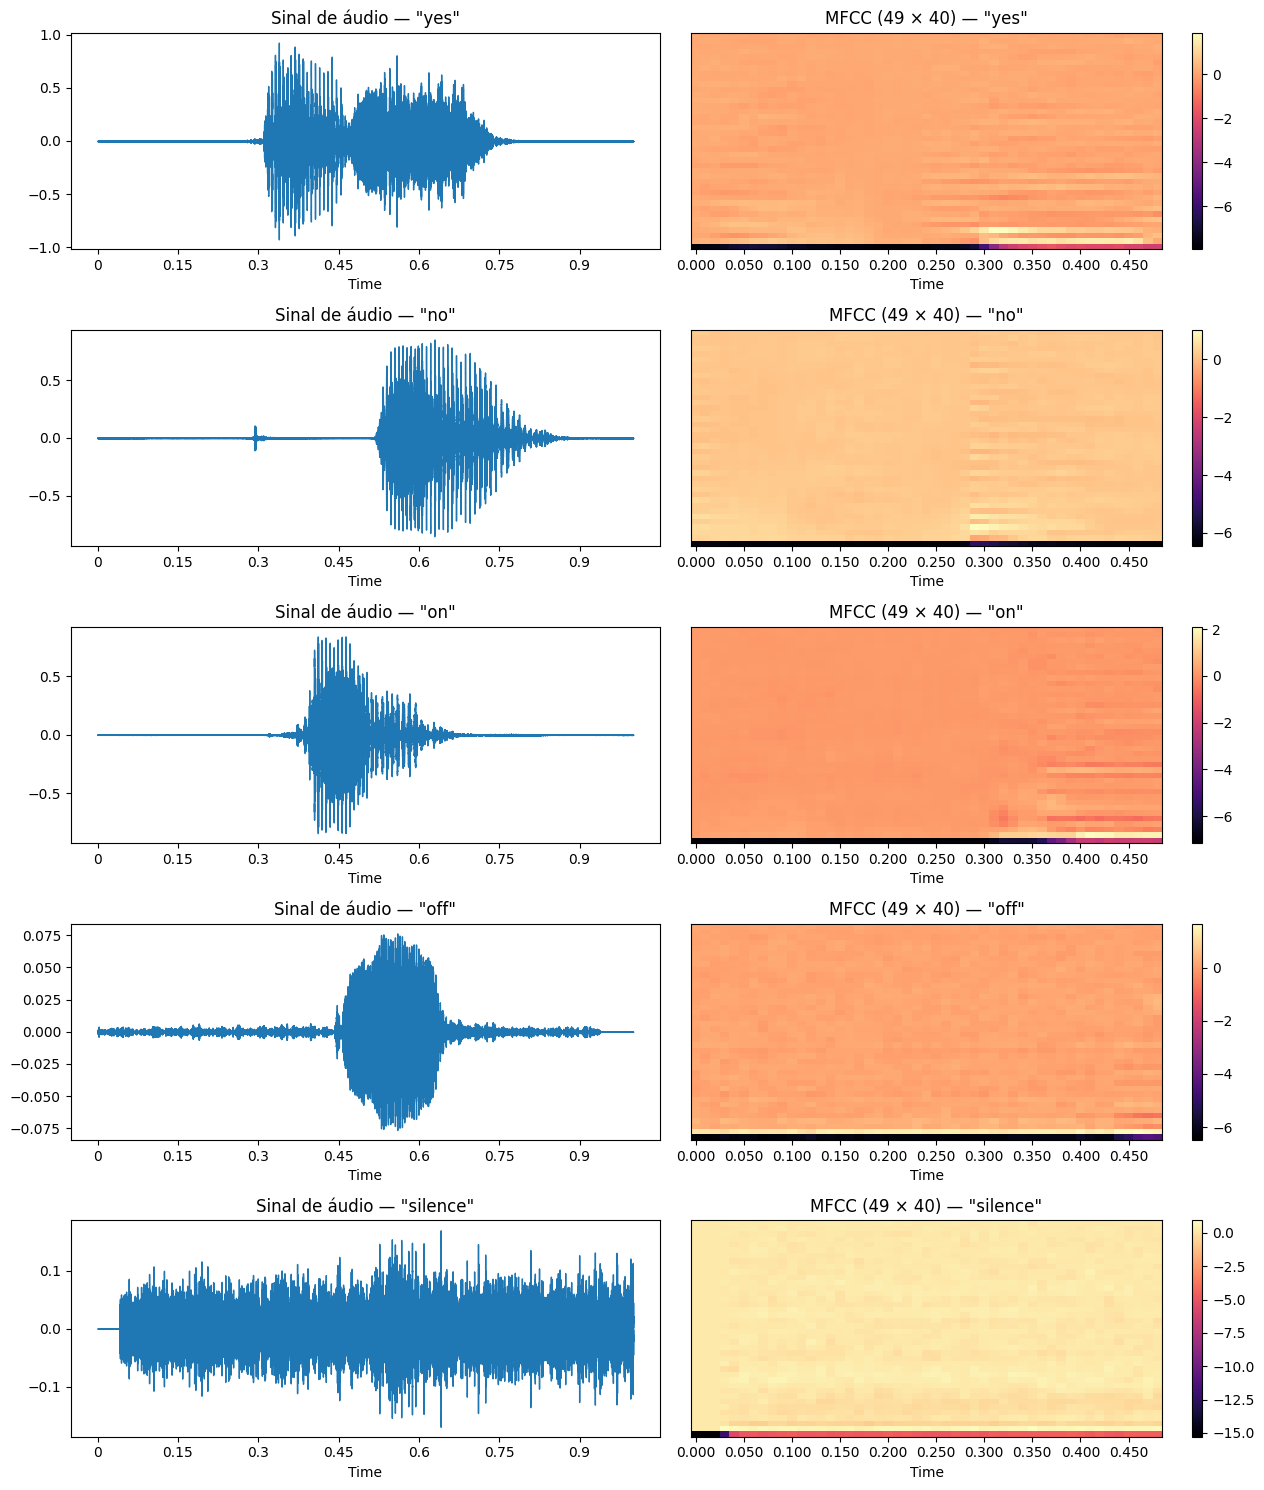

In [21]:
def load_and_pad(path, sr=SAMPLE_RATE, duration=DURATION):
    """Carrega WAV, padeia ou trunca para exatamente NUM_SAMPLES amostras."""
    y, _ = librosa.load(path, sr=sr, duration=duration)
    target = int(sr * duration)
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)))
    else:
        y = y[:target]
    return y


def add_noise(y, noise_factor=0.005):
    """Adiciona ruído gaussiano branco."""
    noise = np.random.randn(len(y))
    return y + noise_factor * noise


def extract_mfcc(y, sr=SAMPLE_RATE, augment=False):
    """
    Extrai coeficientes MFCC de um sinal de áudio.
    Retorna array de forma (MAX_FRAMES, N_MFCC, 1) — canal explícito.
    O canal explícito evita a camada Reshape no modelo, removendo
    o op STRIDED_SLICE não suportado pelo TFLite Micro (Harvard_TinyMLx).
    """
    if augment and random.random() < 0.5:
        y = add_noise(y, noise_factor=random.uniform(0.002, 0.01))
    if augment and random.random() < 0.3:
        shift = random.randint(-800, 800)
        y = np.roll(y, shift)

    mfcc = librosa.feature.mfcc(
        y=y, sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH
    )  # shape: (N_MFCC, frames)

    # Pad ou trunca no eixo temporal
    if mfcc.shape[1] < MAX_FRAMES:
        mfcc = np.pad(mfcc, ((0, 0), (0, MAX_FRAMES - mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :MAX_FRAMES]

    mfcc = mfcc.T  # shape: (MAX_FRAMES, N_MFCC)

    # Normalização por instância (zero-mean, unit-variance)
    mean = mfcc.mean()
    std  = mfcc.std() + 1e-8
    mfcc = (mfcc - mean) / std
    return mfcc[..., np.newaxis]  # shape: (MAX_FRAMES, N_MFCC, 1)


# plota um exemplo de cada classe
silence_dir = DATASET_DIR / '_background_noise_'
silence_files = list(silence_dir.glob('*.wav')) if silence_dir.exists() else []

sample_sources = {}
for label in TARGET_CLASSES:
    files = list((DATASET_DIR / label).glob('*.wav'))
    if files:
        sample_sources[label] = str(files[0])

fig, axes = plt.subplots(len(sample_sources) + 1, 2, figsize=(13, 3 * (len(sample_sources) + 1)))

for row, (label, fp) in enumerate(sample_sources.items()):
    _y = load_and_pad(fp)
    _mfcc = extract_mfcc(_y)
    print(f"[{label}] Shape MFCC: {_mfcc.shape}  |  min={_mfcc.min():.2f}  max={_mfcc.max():.2f}")

    librosa.display.waveshow(_y, sr=SAMPLE_RATE, ax=axes[row, 0])
    axes[row, 0].set_title(f'Sinal de áudio — "{label}"')

    img = librosa.display.specshow(_mfcc[..., 0].T, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                                   x_axis='time', ax=axes[row, 1], cmap='magma')
    axes[row, 1].set_title(f'MFCC (49 × 40) — "{label}"')
    fig.colorbar(img, ax=axes[row, 1])

# Silêncio sintético
if silence_files:
    full, _ = librosa.load(str(silence_files[0]), sr=SAMPLE_RATE)
    _y_sil = full[:NUM_SAMPLES] if len(full) >= NUM_SAMPLES else np.pad(full, (0, NUM_SAMPLES - len(full)))
else:
    _y_sil = np.random.randn(NUM_SAMPLES) * 0.003

_mfcc_sil = extract_mfcc(_y_sil)
print(f"[silence] Shape MFCC: {_mfcc_sil.shape}  |  min={_mfcc_sil.min():.2f}  max={_mfcc_sil.max():.2f}")

librosa.display.waveshow(_y_sil, sr=SAMPLE_RATE, ax=axes[-1, 0])
axes[-1, 0].set_title('Sinal de áudio — "silence"')
img = librosa.display.specshow(_mfcc_sil[..., 0].T, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                               x_axis='time', ax=axes[-1, 1], cmap='magma')
axes[-1, 1].set_title('MFCC (49 × 40) — "silence"')
fig.colorbar(img, ax=axes[-1, 1])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mfcc_exemplo.png', dpi=120)
plt.show()


In [22]:
def build_dataset():
    X, y = [], []

    # Classes-alvo
    for label in TARGET_CLASSES:
        class_dir = DATASET_DIR / label
        if not class_dir.exists():
            print(f"[AVISO] Diretório não encontrado: {class_dir}")
            continue
        files = list(class_dir.glob('*.wav'))
        random.shuffle(files)
        files = files[:SAMPLES_PER_CLASS]
        print(f"  {label}: {len(files)} arquivos")
        for i, fp in enumerate(files):
            try:
                audio = load_and_pad(str(fp))
                augment = (i % 3 != 0)  # 2/3 das amostras com augmentation
                mfcc = extract_mfcc(audio, augment=augment)
                X.append(mfcc)
                y.append(LABEL2IDX[label])
            except Exception as e:
                print(f"  Erro em {fp.name}: {e}")

    # Silêncio sintético
    # Usa clipes de fundo do dataset + segmentos aleatórios de outras classes
    silence_dir = DATASET_DIR / '_background_noise_'
    silence_files = list(silence_dir.glob('*.wav')) if silence_dir.exists() else []
    print(f"  silence: gerando {SILENCE_SAMPLES} amostras sintéticas...")

    for _ in range(SILENCE_SAMPLES):
        if silence_files and random.random() < 0.7:
            fp   = random.choice(silence_files)
            full, _ = librosa.load(str(fp), sr=SAMPLE_RATE)
            if len(full) > NUM_SAMPLES:
                start = random.randint(0, len(full) - NUM_SAMPLES)
                audio = full[start:start + NUM_SAMPLES]
            else:
                audio = np.pad(full, (0, NUM_SAMPLES - len(full)))
            audio += np.random.randn(NUM_SAMPLES) * 0.001
        else:
            audio = np.random.randn(NUM_SAMPLES) * 0.003  # ruído puro
        X.append(extract_mfcc(audio))
        y.append(LABEL2IDX[SILENCE_CLASS])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)
    print(f"\nDataset: {X.shape}  |  labels: {y.shape}")
    return X, y


print("Processando dataset...")
X, y = build_dataset()

Processando dataset...
  yes: 1500 arquivos
  no: 1500 arquivos
  on: 1500 arquivos
  off: 1500 arquivos
  silence: gerando 1500 amostras sintéticas...

Dataset: (7500, 49, 40, 1)  |  labels: (7500,)


In [23]:
# 70% treino | 15% val | 15% teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_model(num_classes: int = NUM_CLASSES,
                input_shape: tuple = (MAX_FRAMES, N_MFCC, 1)) -> keras.Model:
    """
    CNN 2D sobre MFCCs (49×40×1).
    Input já tem dimensão de canal — sem Reshape interno.
    Evita STRIDED_SLICE/EXPAND_DIMS não suportados pelo TFLite Micro
    (Harvard_TinyMLx).
    """
    inputs = keras.Input(shape=input_shape)   # (49, 40, 1)

    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='kws_cnn2d')
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_model()
model.summary()

Model: "kws_cnn2d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 49, 40, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 49, 40, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 49, 40, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,149 (399.02 KB)

 Trainable params: 101,701 (397.27 KB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
BASE_DIR = pathlib.Path('.')
OUTPUTS_DIR = BASE_DIR / 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = OUTPUTS_DIR / 'best_kws_model.keras'

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.4435 - loss: 1.2998
Epoch 1: val_accuracy improved from None to 0.20089, saving model to outputs/best_kws_model.keras

Epoch 1: finished saving model to outputs/best_kws_model.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 393ms/step - accuracy: 0.5272 - loss: 1.1325 - val_accuracy: 0.2009 - val_loss: 1.8606 - learning_rate: 0.0010
Epoch 2/50
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.6114 - loss: 0.9234
Epoch 2: val_accuracy did not improve from 0.20089
83/83 ━━━━━━━━━━━━━━━━━━━━ 41s 394ms/step - accuracy: 0.6423 - loss: 0.8534 - val_accuracy: 0.2000 - val_loss: 3.3666 - learning_rate: 0.0010
Epoch 3/50
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6803 - loss: 0.7972
Epoch 3: val_accuracy did not improve from 0.20089
83/83 ━━━━━━━━━━━━━━━━━━━━ 31s 370ms/step - accuracy: 0.7051 - loss: 0.7313 - val_accuracy: 0.2009 - val_loss: 5.4077 - learning_rate: 0.0010
Epoch 4/50
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step 

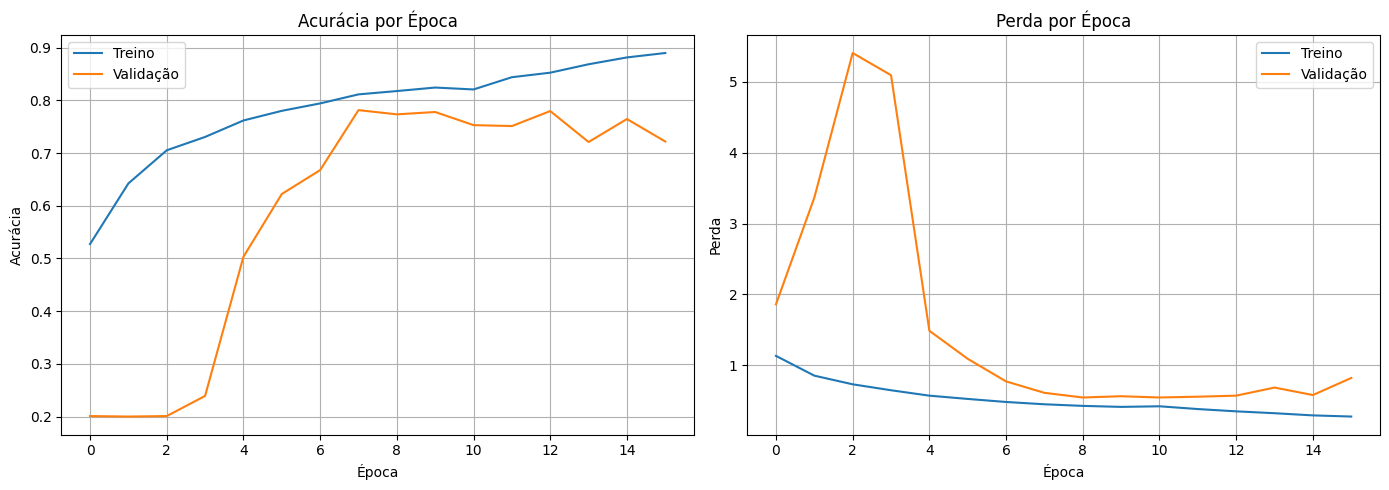

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Treino')
axes[0].plot(history.history['val_accuracy'], label='Validação')
axes[0].set_title('Acurácia por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Treino')
axes[1].plot(history.history['val_loss'], label='Validação')
axes[1].set_title('Perda por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Perda')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kws_curvas.png', dpi=150)
plt.show()

Acurácia no conjunto de teste: 0.7467 | Loss: 0.6169

36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step
              precision    recall  f1-score   support

         yes       0.81      0.83      0.82       225
          no       0.92      0.72      0.81       225
          on       0.64      0.58      0.61       225
         off       0.66      0.60      0.63       225
     silence       0.72      1.00      0.84       225

    accuracy                           0.75      1125
   macro avg       0.75      0.75      0.74      1125
weighted avg       0.75      0.75      0.74      1125



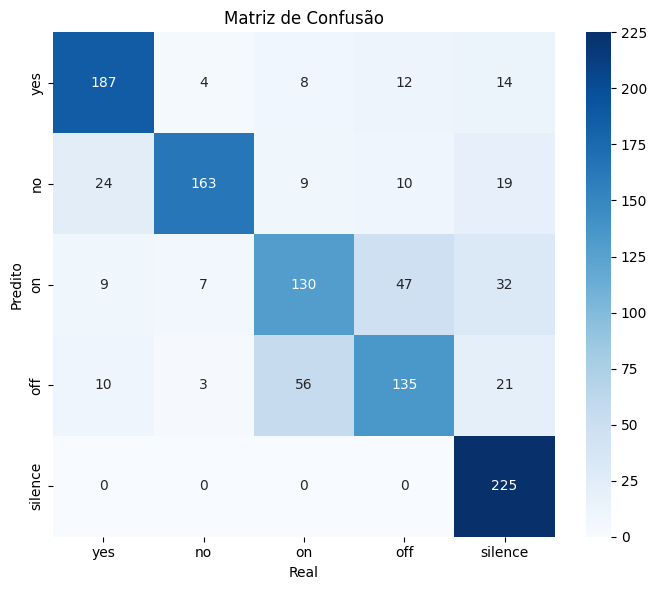

In [28]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Acurácia no conjunto de teste: {test_acc:.4f} | Loss: {test_loss:.4f}\n")

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=ALL_LABELS))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ALL_LABELS, yticklabels=ALL_LABELS)
plt.title('Matriz de Confusão')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kws_matriz_confusao.png', dpi=150)
plt.show()

In [29]:
params = {
    "target_classes": TARGET_CLASSES,
    "all_labels": ALL_LABELS,
    "num_samples": NUM_SAMPLES,
    "n_fft": N_FFT,
    "n_mfcc": N_MFCC,
    "hop_length": HOP_LENGTH,
    "win_length": WIN_LENGTH,
    "max_frames": MAX_FRAMES,
    "normalization": "per-instance zero-mean unit-variance",
    "test_accuracy": float(test_acc),
}

params_path = OUTPUT_DIR / 'kws_params.json'
with open(params_path, 'w') as f:
  json.dump(params, f, indent=2)

print(f" Acurácia : {test_acc:.4f}")
print(f" Classes : {ALL_LABELS}")

 Acurácia : 0.7467
 Classes : ['yes', 'no', 'on', 'off', 'silence']


In [33]:
import shutil
import subprocess
from pathlib import Path

# Ajustado para o caminho padrão do Google Colab
WORKSPACE = Path('/content')
OUTPUTS_DIR = WORKSPACE / 'outputs'
ARDUINO_DIR = WORKSPACE / 'arduino' / 'inferencia_kws'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
ARDUINO_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUTS_DIR / 'best_kws_model.keras'
TFLITE_FLOAT_PATH = OUTPUTS_DIR / 'kws_float32.tflite'
TFLITE_INT8_PATH =  OUTPUTS_DIR / 'kws_int8.tflite'
HEADER_PATH = ARDUINO_DIR / 'kws_model_data.h'

NUM_FRAMES = 49
NUM_MFCC = 40

In [36]:
import random
import numpy as np
import librosa
import tensorflow as tf

# Carrega o modelo usando o caminho corrigido
model = tf.keras.models.load_model(str(MODEL_PATH))
model.summary()

NUM_CALIB = 200
calib_samples = []

print("Gerando dados de calibração para as classes alvo...")
for label in TARGET_CLASSES:
    files = list(DATASET_DIR / label).glob('*.wav')
    random.shuffle(files)
    for fp in files[:NUM_CALIB]:
        try:
            audio = load_and_pad(str(fp))
            mfcc = extract_mfcc(audio)
            calib_samples.append(mfcc)
        except Exception:
            pass

print("Gerando dados de calibração para ruído de fundo...")
noise_dir = DATASET_DIR / '_background_noise_'
if noise_dir.exists():
    noise_files = list(noise_dir.glob('*.wav'))
    for fp in noise_files[:5]:
        full, _ = librosa.load(str(fp), sr=SAMPLE_RATE)
        for _ in range(40):
            if len(full) > NUM_SAMPLES:
                s = random.randint(0, len(full) - NUM_SAMPLES)
                seg = full[s:s + NUM_SAMPLES]
            else:
                seg = np.pad(full, (0, NUM_SAMPLES - len(full)))
            calib_samples.append(extract_mfcc(seg.astype(np.float32)))

random.shuffle(calib_samples)
calib_arr = np.array(calib_samples, dtype=np.float32)
print(f'\nShape do array de calibração: {calib_arr.shape}')

Model: "kws_cnn2d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 49, 40, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 49, 40, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 49, 40, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,553 (1.17 MB)

 Trainable params: 101,701 (397.27 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 203,404 (794.55 KB)

Gerando dados de calibração para as classes alvo...


TypeError: 'PosixPath' object is not iterable

In [39]:
import tensorflow as tf
import numpy as np
import random

# --- 0. Garantir dados de calibração ---
print("Preparando calib_arr para quantização...")
calib_samples = []
NUM_CALIB = 100

for label in TARGET_CLASSES:
    # Correção: Primeiro chamamos .glob e depois convertemos para list
    files = list((DATASET_DIR / label).glob('*.wav'))
    random.shuffle(files)
    for fp in files[:NUM_CALIB]:
        try:
            audio = load_and_pad(str(fp))
            mfcc = extract_mfcc(audio)
            calib_samples.append(mfcc)
        except Exception:
            pass

calib_arr = np.array(calib_samples, dtype=np.float32)
print(f"Dados de calibração prontos: {calib_arr.shape}")

# --- 1. Converter para TFLite Float32 ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float_model = converter.convert()
with open(TFLITE_FLOAT_PATH, 'wb') as f:
    f.write(tflite_float_model)
print(f"Modelo Float32 salvo em: {TFLITE_FLOAT_PATH}")

# --- 2. Converter para TFLite Int8 (Quantização Full Integer) ---
def representative_dataset():
    for i in range(len(calib_arr)):
        yield [calib_arr[i:i+1]]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8_model = converter.convert()
with open(TFLITE_INT8_PATH, 'wb') as f:
    f.write(tflite_int8_model)
print(f"Modelo Int8 quantizado salvo em: {TFLITE_INT8_PATH}")

# --- 3. Gerar arquivo de cabeçalho C para Arduino ---
print("Gerando arquivo .h para Arduino...")
!apt-get -qq install xxd
!xxd -i {TFLITE_INT8_PATH} > {HEADER_PATH}

# Ajustar o nome da variável no arquivo .h
with open(HEADER_PATH, 'r') as f:
    content = f.read()
content = content.replace('unsigned char kws_int8_tflite', 'const unsigned char g_kws_model_data')
with open(HEADER_PATH, 'w') as f:
    f.write(content)

print(f"Sucesso! O cabeçalho foi salvo em: {HEADER_PATH}")

Preparando calib_arr para quantização...
Dados de calibração prontos: (400, 49, 40, 1)
Saved artifact at '/tmp/tmpgez_ai13'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 40, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138062866336080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866334928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866336272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866337232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866337040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866336464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866336848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866334736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866334544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

In [41]:
converter_f32 = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_f32 = converter_f32.convert()

with open(TFLITE_FLOAT_PATH, 'wb') as f:
  f.write(tflite_f32)

print(f"Float32 salvo : {TFLITE_FLOAT_PATH}")
print(f"Tamanho : {len(tflite_f32) / 1024:.1f} KB")

Saved artifact at '/tmp/tmp3mc529d2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 40, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138062866336080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866334928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866336272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866337232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866337040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866336464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866336848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866334736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866334544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866338384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866338192: 

In [43]:
def representative_dataset():
  for i in range(len(calib_arr)):
    yield [calib_arr[i:i+1]]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.int8
converter_int8.inference_output_type = tf.int8

tflite_int8 = converter_int8.convert()

with open(TFLITE_INT8_PATH, 'wb') as f:
  f.write(tflite_int8)

Saved artifact at '/tmp/tmp5sx8ghmi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 40, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138062866336080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866334928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866336272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866337232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866337040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866336464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866336848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866334736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866334544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866338384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062866338192: 

In [45]:
import subprocess
import re

def bytes_to_c_array(data: bytes, var_name: str = 'kws_model_data') -> str:
  hex_vals = ', '.join(f'0x{b:02x}' for b in data)
  chunks = [hex_vals[i:i+12*6] for i in range(0, len(hex_vals), 12*6)]
  body = ',\n '.join(chunks)
  header = f"""\
#ifndef KWS_MODEL_DATA_H_
#define KWS_MODEL_DATA_H_

const unsigned char {var_name}[] = {{
  {body}
}};
const unsigned int {var_name}_len = {len(data)};

#endif // KWS_MODEL_DATA_H_
"""
  return header

try:
  result = subprocess.run(
      ['xxd', '-i', str(TFLITE_INT8_PATH)],
      capture_output=True, text=True, check=True
  )
  raw = result.stdout
  raw = re.sub(r'unsigned char \w+\[\]', 'const unsigned char kws_model_data[]', raw)
  raw = re.sub(r'unsigned int \w+_len', 'const unsigned int kws_model_data_len', raw)
  # Corrigido: Usando header_content e adicionando o # no ifndef
  header_content = (
      "#ifndef KWS_MODEL_DATA_H_\n#define KWS_MODEL_DATA_H_\n\n"
      + raw +
      "\n#endif // KWS_MODEL_DATA_H_\n"
  )
  print("xxd utilizado para gerar o header.")
except Exception:
  header_content = bytes_to_c_array(tflite_int8)
  print("Python puro utilizado para gerar o header (xxd nao disponivel).")

HEADER_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(HEADER_PATH, 'w') as f:
  f.write(header_content)

print(f"Sucesso! Arquivo de cabeçalho salvo em: {HEADER_PATH}")

xxd utilizado para gerar o header.
Sucesso! Arquivo de cabeçalho salvo em: /content/arduino/inferencia_kws/kws_model_data.h
